<h2 align=center> Fine-Tune BERT for Text Classification with TensorFlow</h2>

<div align="center">
    <img width="512px" src='https://drive.google.com/uc?id=1fnJTeJs5HUpz7nix-F9E6EZdgUflqyEu' />
    <p style="text-align: center;color:gray">Figure 1: BERT Classification Model</p>
</div>

In this project, we will fine-tune a BERT model for text classification using TensorFlow and TF-Hub. The pretrained BERT model used in this project is [available](https://www.kaggle.com/models/tensorflow/bert/tensorFlow2/en-uncased-l-12-h-768-a-12/2) on [Kaggle Models](https://www.kaggle.com/models).

### Objectives
- Build TensorFlow Input Pipelines for Text Data with the [`tf.data`](https://www.tensorflow.org/api_docs/python/tf/data) API
- Tokenize and Preprocess Text for BERT
- Fine-tune BERT for text classification with TensorFlow 2 and [TF Hub](https://tfhub.dev)

### Contents
This project consists of the following Tasks.

- **Task 1**: Setup TensorFlow and Colab Runtime
- **Task 2**: Download and Import the Quora Insincere Questions Dataset
- **Task 3**: Create tf.data.Datasets for Training and Evaluation
- **Task 4**: Download a Pre-trained BERT Model from TensorFlow Hub
- **Task 5**: Tokenize and Preprocess Text for BERT
- **Task 6**: Wrap a Python Function into a TensorFlow op for Eager Execution
- **Task 7**: Create a TensorFlow Input Pipeline with `tf.data`
- **Task 8**: Add a Classification Head to the BERT `hub.KerasLayer`
- **Task 9**: Fine-Tune BERT for Text Classification
- **Task 10**: Evaluate the BERT Text Classification Model

## Task 1: Setup TensorFlow and Colab Runtime.

In [ ]:
# Check GPU Availability
!nvidia-smi

Sun Apr 19 11:12:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install TensorFlow and TensorFlow Model Garden

In [ ]:
import tensorflow as tf
print(tf.version.VERSION)

2.19.0


In [ ]:
!git clone --depth 1 -b v2.3.0 https://github.com/tensorflow/models.git

In [ ]:
# install requirements to use tensorflow/models repository
!grep -v "tensorflow-addons" models/official/requirements.txt > requirements_modified.txt
!pip install -Uqr requirements_modified.txt

## Task 2: Download and Import the Quora Insincere Questions Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow_hub as hub
import sys

!pip install tf_keras
import tf_keras

try:
    import tensorflow_addons
except ImportError:
    import types
    mock_tfa = types.ModuleType("tensorflow_addons")
    mock_tfa.optimizers = types.ModuleType("optimizers")
    sys.modules["tensorflow_addons"] = mock_tfa
    sys.modules["tensorflow_addons.optimizers"] = mock_tfa.optimizers

sys.path.append('models')
from official.nlp.data import classifier_data_lib
from official.nlp.bert import tokenization
from official.nlp import optimization

In [ ]:
print("TF Version: ", tf.__version__)
print("Eager mode: ", tf.executing_eagerly())
print("Hub version: ", hub.__version__)
print("GPU is", "available" if tf.config.experimental.list_physical_devices("GPU") else "NOT AVAILABLE")

TF Version:  2.19.0
Eager mode:  True
Hub version:  0.16.1
GPU is available


A downloadable copy of the [Quora Insincere Questions Classification data](https://www.kaggle.com/c/quora-insincere-questions-classification/data) can be found [https://archive.org/download/fine-tune-bert-tensorflow-train.csv/train.csv.zip](https://archive.org/download/fine-tune-bert-tensorflow-train.csv/train.csv.zip). Decompress and read the data into a pandas DataFrame.

In [ ]:
df = pd.read_csv("https://archive.org/download/fine-tune-bert-tensorflow-train.csv/train.csv.zip", compression = 'zip', low_memory = False)

df.shape


(1306122, 3)

In [ ]:
df.tail(20)

,qid,question_text,target
1306102,ffff3778790af9baae76,What steps can I take to live a normal life if...,0
1306103,ffff3f0a2449ffe4b9ff,Isn't Trump right after all? Why should the US...,1
1306104,ffff41393389d4206066,Is 33 too late for a career in creative advert...,0
1306105,ffff42493fc203cd9532,What is difference between the filteration wor...,0
1306106,ffff48dd47bee89fff79,"If the universe ""popped"" into existence from n...",0
1306107,ffff5fd051a032f32a39,How does a shared service technology team meas...,0
1306108,ffff6d528040d3888b93,How is DSATM civil engineering?,0
1306109,ffff8776cd30cdc8d7f8,Do you know any problem that depends solely on...,0
1306110,ffff94d427ade3716cd1,What are some comic ideas for you Tube videos ...,0
1306111,ffffa382c58368071dc9,"If you had $10 million of Bitcoin, could you s...",0


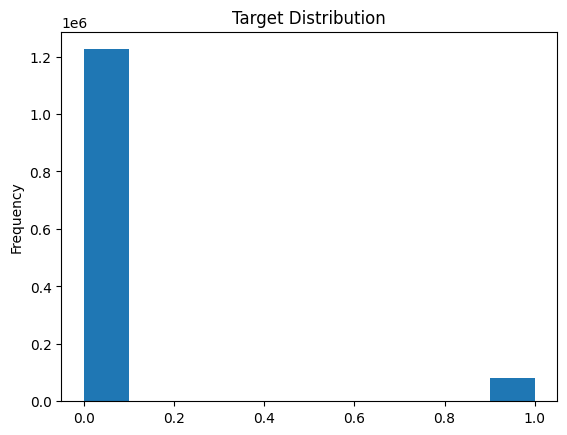

In [ ]:
df.target.plot(kind = 'hist', title = 'Target Distribution')
plt.show()

## Task 3: Create tf.data.Datasets for Training and Evaluation

In [ ]:
train_df, remaining = train_test_split(df, random_state = 42, train_size = 0.0075, stratify = df.target.values)

valid_df, _ = train_test_split(remaining, random_state = 42, train_size = 0.00075, stratify = remaining.target.values)

train_df.shape, valid_df.shape

((9795, 3), (972, 3))

In [ ]:
with tf.device('/cpu:0'):
  train_data = tf.data.Dataset.from_tensor_slices((train_df['question_text'].values, train_df['target'].values))

  valid_data = tf.data.Dataset.from_tensor_slices((valid_df.question_text.values, valid_df.target.values))

  for text, label in train_data.take(3):
    print(text)
    print(label)

tf.Tensor(b'Why are unhealthy relationships so desirable?', shape=(), dtype=string)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(b'Which war changed the course of history of the world?', shape=(), dtype=string)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(b"I have started a YouTube channel named AskHamy (link is given below). The problem is that I don't want to show myself and instead just want to do a voice-over. What are some things which I can show on screen so that the viewers don't get bored?", shape=(), dtype=string)
tf.Tensor(0, shape=(), dtype=int64)


## Task 4: Download a Pre-trained BERT Model from TensorFlow Hub

In [ ]:
label_list = [0, 1]
max_seq_length = 128
train_batch_size = 32

bert_layer = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/2", trainable=True)

vocab_file = bert_layer.resolved_object.vocab_file.asset_path.numpy()
do_lower_case = bert_layer.resolved_object.do_lower_case.numpy()
tokenizer = tokenization.FullTokenizer(vocab_file, do_lower_case)

In [ ]:
tokenizer.wordpiece_tokenizer.tokenize('hi, how are you doing?')

['hi', '##,', 'how', 'are', 'you', 'doing', '##?']

In [ ]:
tokenizer.convert_tokens_to_ids(tokenizer.wordpiece_tokenizer.tokenize('hi, how are you doing?'))

[7632, 29623, 2129, 2024, 2017, 2725, 29632]

## Task 5: Tokenize and Preprocess Text for BERT

<div align="center">
    <img width="512px" src='https://drive.google.com/uc?id=1-SpKFELnEvBMBqO7h3iypo8q9uUUo96P' />
    <p style="text-align: center;color:gray">Figure 2: BERT Tokenizer</p>
</div>

We'll need to transform our data into a format BERT understands. This involves two steps. First, we create InputExamples using `classifier_data_lib`'s constructor `InputExample` provided in the BERT library.

In [ ]:
# This provides a function to convert row to input features and label

def to_feature(text, label, label_list=label_list, max_seq_length=max_seq_length, tokenizer=tokenizer):
  example = classifier_data_lib.InputExample(guid = None,
                                             text_a = text.numpy(),
                                             text_b = None,
                                             label = label.numpy())
  feature = classifier_data_lib.convert_single_example(0, example, label_list, max_seq_length, tokenizer)

  return (feature.input_ids, feature.input_mask, feature.segment_ids, feature.label_id)

You want to use [`Dataset.map`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#map) to apply this function to each element of the dataset. [`Dataset.map`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#map) runs in graph mode.

- Graph tensors do not have a value.
- In graph mode you can only use TensorFlow Ops and functions.

So you can't `.map` this function directly: You need to wrap it in a [`tf.py_function`](https://www.tensorflow.org/api_docs/python/tf/py_function). The [`tf.py_function`](https://www.tensorflow.org/api_docs/python/tf/py_function) will pass regular tensors (with a value and a `.numpy()` method to access it), to the wrapped python function.

## Task 6: Wrap a Python Function into a TensorFlow op for Eager Execution

In [ ]:
def to_feature_map(text, label):
  input_ids, input_mask, segment_ids, label_id = tf.py_function(
      to_feature,
      inp=[text, label],
      Tout=[tf.int32, tf.int32, tf.int32, tf.int32]
  )

  input_ids.set_shape([max_seq_length])
  input_mask.set_shape([max_seq_length])
  segment_ids.set_shape([max_seq_length])
  label_id.set_shape([])

  x = {
      'input_word_ids': input_ids,
      'input_mask': input_mask,
      'input_type_ids': segment_ids
  }

  return (x, label_id)

## Task 7: Create a TensorFlow Input Pipeline with `tf.data`

In [ ]:
with tf.device('/cpu:0'):
  # train
  train_data = (train_data.map(to_feature_map,
                               num_parallel_calls = tf.data.experimental.AUTOTUNE)
  .shuffle(1000)
  .batch(32, drop_remainder = True)
  .prefetch(tf.data.experimental.AUTOTUNE))

  # valid
  valid_data = (valid_data.map(to_feature_map,
                               num_parallel_calls = tf.data.experimental.AUTOTUNE)
  .batch(32, drop_remainder = True)
  .prefetch(tf.data.experimental.AUTOTUNE))

The resulting `tf.data.Datasets` return `(features, labels)` pairs, as expected by [`keras.Model.fit`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit):

In [ ]:
# train data spec
train_data.element_spec

({'input_word_ids': TensorSpec(shape=(32, 128), dtype=tf.int32, name=None),
  'input_mask': TensorSpec(shape=(32, 128), dtype=tf.int32, name=None),
  'input_type_ids': TensorSpec(shape=(32, 128), dtype=tf.int32, name=None)},
 TensorSpec(shape=(32,), dtype=tf.int32, name=None))

In [ ]:
# valid data spec
valid_data.element_spec

({'input_word_ids': TensorSpec(shape=(32, 128), dtype=tf.int32, name=None),
  'input_mask': TensorSpec(shape=(32, 128), dtype=tf.int32, name=None),
  'input_type_ids': TensorSpec(shape=(32, 128), dtype=tf.int32, name=None)},
 TensorSpec(shape=(32,), dtype=tf.int32, name=None))

## Task 8: Add a Classification Head to the BERT Layer

<div align="center">
    <img width="512px" src='https://drive.google.com/uc?id=1fnJTeJs5HUpz7nix-F9E6EZdgUflqyEu' />
    <p style="text-align: center;color:gray">Figure 3: BERT Layer</p>
</div>

In [ ]:
def create_model():
    
    input_word_ids = tf_keras.layers.Input(
        shape=(max_seq_length,), dtype=tf.int32, name="input_word_ids"
    )
    input_mask = tf_keras.layers.Input(
        shape=(max_seq_length,), dtype=tf.int32, name="input_mask"
    )
    input_type_ids = tf_keras.layers.Input(
        shape=(max_seq_length,), dtype=tf.int32, name="input_type_ids"
    )

    pooled_output, sequence_output = bert_layer(
        [input_word_ids, input_mask, input_type_ids]
    )

    drop = tf_keras.layers.Dropout(0.4)(pooled_output)
    output = tf_keras.layers.Dense(
        1, activation='sigmoid', name="output"
    )(drop)

    model = tf_keras.Model(
        inputs={
            'input_word_ids': input_word_ids,
            'input_mask': input_mask,
            'input_type_ids': input_type_ids
        },
        outputs=output
    )

    return model

## Task 9: Fine-Tune BERT for Text Classification

In [ ]:
model = create_model()

model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf_keras.losses.BinaryCrossentropy(),
    metrics=[tf_keras.metrics.BinaryAccuracy()]
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_word_ids (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 input_mask (InputLayer)     [(None, 128)]                0         []                            
                                                                                                  
 input_type_ids (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                              

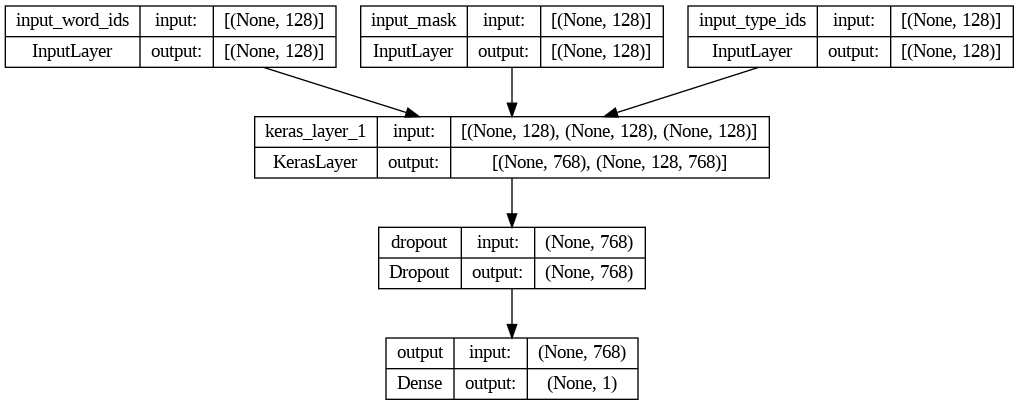

In [ ]:
tf_keras.utils.plot_model(model = model, show_shapes = True)

In [ ]:
# Train model
epochs = 4

history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=epochs,
    verbose=1
)

Epoch 1/4
306/306 [==============================] - 320s 851ms/step - loss: 0.1583 - binary_accuracy: 0.9420 - val_loss: 0.1216 - val_binary_accuracy: 0.9542
Epoch 2/4
306/306 [==============================] - 258s 839ms/step - loss: 0.0970 - binary_accuracy: 0.9645 - val_loss: 0.1212 - val_binary_accuracy: 0.9583
Epoch 3/4
306/306 [==============================] - 260s 845ms/step - loss: 0.0482 - binary_accuracy: 0.9823 - val_loss: 0.1838 - val_binary_accuracy: 0.9583
Epoch 4/4
306/306 [==============================] - 263s 856ms/step - loss: 0.0207 - binary_accuracy: 0.9940 - val_loss: 0.2144 - val_binary_accuracy: 0.9573


## Task 10: Evaluate the BERT Text Classification Model

In [ ]:
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])
  plt.show()

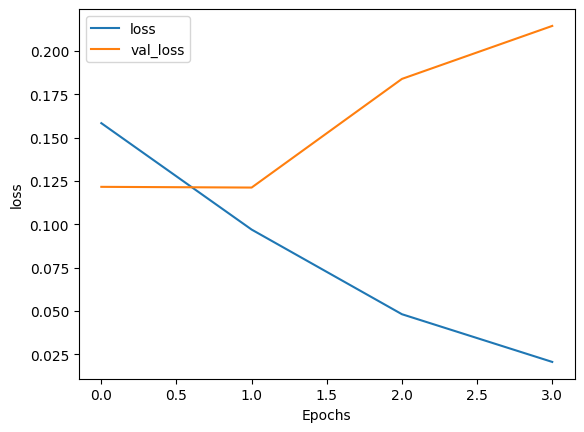

In [ ]:
plot_graphs(history, 'loss')

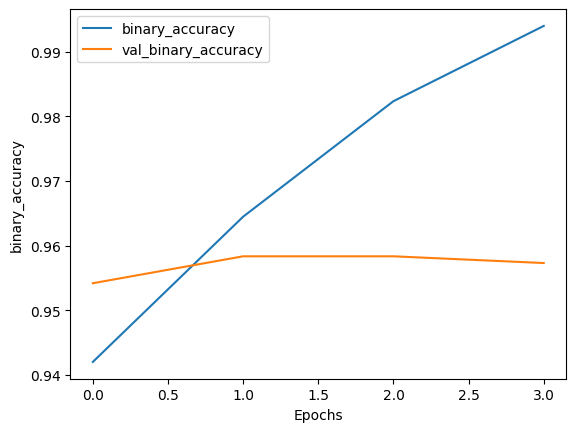

In [ ]:
plot_graphs(history, 'binary_accuracy')

In [ ]:
sample_example = ["May I please have your email id?",
                  "The world is cruel, but it is also very beautiful.",
                  "What a surprising turn of events!",
                  "This guy hates everyone because he thinks that everyone is retarded",
                  "The weather is nice today."]
test_data = tf.data.Dataset.from_tensor_slices((sample_example, [0]*len(sample_example)))
test_data = (test_data.map(to_feature_map).batch(1))
preds = model.predict(test_data)
threshold = 0.7 # Between 0 & 1
['Insincere' if pred >= threshold else 'Sincere' for pred in preds]

5/5 [==============================] - 0s 22ms/step


['Sincere', 'Sincere', 'Sincere', 'Insincere', 'Sincere']